In [ ]:
# Step 1 - Import Required Library -The pandas library is imported(the pd is an alias for pandas - similar to database in sql) - click run

In [44]:
import pandas as pd

In [45]:
import matplotlib.pyplot as plt

In [46]:
#import numpy as np

In [47]:
# Step 2 - # read_csv File Data to be loaded into pandas Data Frame (similar to tables in sql) - click run

In [48]:
myFlights = pd.read_csv("/anvil/projects/tdm/data/flights/subset/1990.csv") 
myairDF = pd.read_csv("/anvil/projects/tdm/data/flights/subset/airports.csv")


In [49]:
# Step 3 - # Display first 5 rows of data from the election donations data frame(similar to Top 5 in sql) - click run

In [50]:
myFlights.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,1990,1,3,3,1707.0,1630,1755.0,1723,US,29,...,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN
1,1990,1,4,4,1706.0,1630,1807.0,1723,US,29,...,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN
2,1990,1,5,5,1629.0,1630,1715.0,1723,US,29,...,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN
3,1990,1,6,6,1633.0,1630,1718.0,1723,US,29,...,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN
4,1990,1,8,1,1630.0,1630,1726.0,1723,US,29,...,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN


In [51]:
myairDF.head()

,iata,airport,city,state,country,lat,long
0,00M,Thigpen,Bay Springs,MS,USA,31.953765,-89.234505
1,00R,Livingston Municipal,Livingston,TX,USA,30.685861,-95.017928
2,00V,Meadow Lake,Colorado Springs,CO,USA,38.945749,-104.569893
3,01G,Perry-Warsaw,Perry,NY,USA,42.741347,-78.052081
4,01J,Hilliard Airpark,Hilliard,FL,USA,30.688012,-81.905944


In [52]:
def monthlydepdelays (myyear: int) -> pd.Series:
    """
    The monthlydepdelays function takes a year as the input,
    and returns a Series with the average departure delay for flights originating from Indianapolis airport
    for each month of that year.

    Args:
    myyear (int): This is the year for which to analyze flight delays

    Returns:
    monthlydepdelays (pd.Series): This is a Series of length 12 containing the average departure delay for each month of flights departing from Indianapolis airport.
    """
    myflights = pd.read_csv("/anvil/projects/tdm/data/flights/subset/" + str(myyear) + ".csv", usecols=[1, 15, 16]) ## Column 1 (index 1) is the Month column Column 15 (index 15) is the DepDelay column Column 16 (index 16) is the Origin column
    indy_Flights = myflights[myflights['Origin'] == 'IND']
    monthlydepdelays = indy_Flights.groupby('Month')['DepDelay'].mean()
 
    return monthlydepdelays

In [53]:
## Pandas Series indexed by month (1 to 12), with each value representing the average departure delay for flights departing from Indianapolis airport in that month.

In [54]:
monthlydepdelays(1990)

Month
1     7.282772
2     9.497027
3     6.924841
4     4.949858
5     5.471487
6     6.010835
7     4.307377
8     5.639782
9     4.455586
10    4.473725
11    3.408304
12    9.764105
Name: DepDelay, dtype: float64

In [55]:
monthlydepdelays(1998)

Month
1      6.314439
2      5.866770
3      9.898317
4      7.766752
5      8.980092
6     15.866469
7      7.579602
8      5.765383
9      3.122498
10     5.169646
11     4.346535
12     9.228510
Name: DepDelay, dtype: float64

In [56]:
monthlydepdelays(2005)

Month
1      7.689248
2      4.956196
3      6.881828
4      2.988902
5      1.302440
6      8.472591
7     12.218633
8      6.812698
9      2.795146
10     4.850184
11     4.897145
12    11.572550
Name: DepDelay, dtype: float64

In [ ]:
# Call the monthlydepdelays function for the years 1988-1993 and store the result in results1988 - results1993

Text(0.5, 1.0, '1993 Delays')

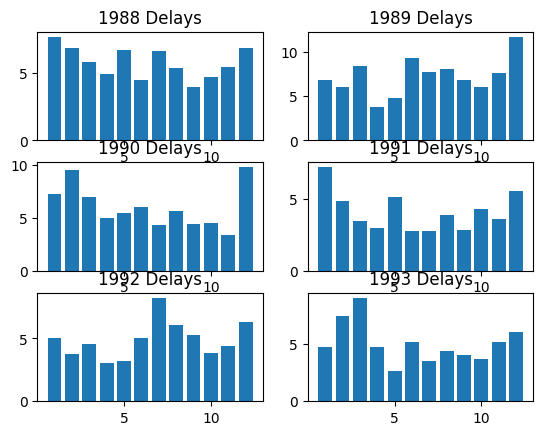

In [60]:
results1988 = monthlydepdelays(1988)
results1989 = monthlydepdelays(1989)
results1990 = monthlydepdelays(1990)
results1991 = monthlydepdelays(1991)
results1992 = monthlydepdelays(1992)
results1993 = monthlydepdelays(1993)
fig, axs = plt.subplots(3, 2)

axs[0, 0].bar(results1988.index, results1988) # Plot a bar chart of the 1988 monthly delays on the first subplot (top-left)
axs[0, 0].set_title("1988 Delays") # Set the title of the first subplot to "1988 Delays"
axs[0, 1].bar(results1989.index, results1989)  # Plot a bar chart of the 1989 monthly delays on the second subplot (top-right)
axs[0, 1].set_title("1989 Delays") # Set the title of the second subplot to "1989 Delays"
axs[1, 0].bar(results1990.index, results1990) # Plot a bar chart of the 1990 monthly delays on the third subplot (middle-left)
axs[1, 0].set_title("1990 Delays") # Set the title of the third subplot to "1990 Delays"
axs[1, 1].bar(results1991.index, results1991) # Plot a bar chart of the 1991 monthly delays on the fourth subplot (middle-right)
axs[1, 1].set_title("1991 Delays") # Set the title of the fourth subplot to "1991 Delays"
axs[2, 0].bar(results1992.index, results1992) # Plot a bar chart of the 1992 monthly delays on the fifth subplot (bottom-left)
axs[2, 0].set_title("1992 Delays") # Set the title of the fifth subplot to "1992 Delays"
axs[2, 1].bar(results1993.index, results1993) # Plot a bar chart of the 1993 monthly delays on the sixth subplot (bottom-right)
axs[2, 1].set_title("1993 Delays") # Set the title of the sixth subplot to "1993 Delays"